# Introduction to Functions in Mathematics

Welcome to this educational notebook on functions! Functions are one of the most fundamental concepts in mathematics and form the foundation for calculus and machine learning.

## Learning Objectives
By the end of this notebook, you will understand:
- What a function is and how to think about it conceptually
- Common mathematical notation for functions
- Real-world examples of functions
- How functions relate to machine learning and data science
- The creative process of selecting functions to model real-world phenomena

## What is a Function?

At its core, **a function is a relationship between inputs and an output**. Think of it as a machine that takes one or more inputs and produces exactly one output.

### Everyday Analogies
- **Coffee Machine**: Input beans and water → Output coffee
- **Calculator**: Input numbers and operation → Output result  
- **GPS Navigation**: Input starting point and destination → Output route

### Mathematical Definition
A function $f$ assigns to each input value $x$ from a set (called the domain) exactly one output value $f(x)$ from another set (called the range).

f(-2) = -2^2 + 3 = 7
f(-1) = -1^2 + 3 = 4
f(0) = 0^2 + 3 = 3
f(1) = 1^2 + 3 = 4
f(2) = 2^2 + 3 = 7


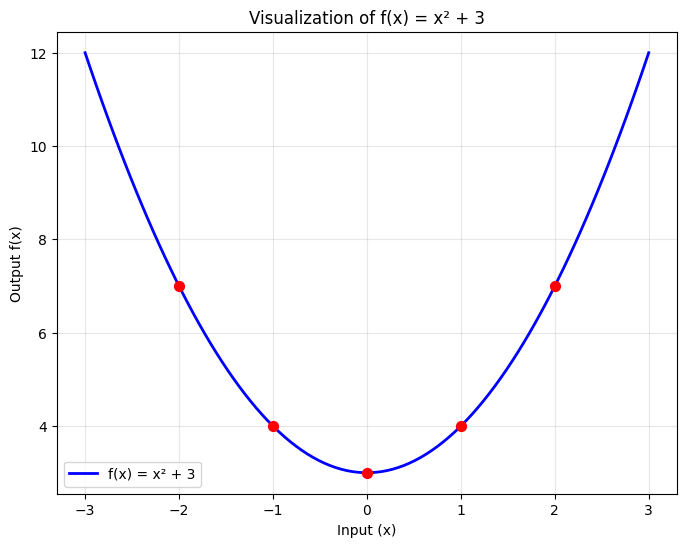


Notice: Each input x produces exactly ONE output f(x)


In [1]:
# Let's start with simple function examples
import numpy as np
import matplotlib.pyplot as plt

# Example 1: A simple function f(x) = x^2 + 3
def f(x):
    return x**2 + 3

# Test with some inputs
x_values = [-2, -1, 0, 1, 2]
for x in x_values:
    print(f"f({x}) = {x}^2 + 3 = {f(x)}")

# Visualize the function
x = np.linspace(-3, 3, 100)
y = f(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y, 'b-', linewidth=2, label='f(x) = x² + 3')
plt.scatter(x_values, [f(x) for x in x_values], color='red', s=50, zorder=5)
plt.xlabel('Input (x)')
plt.ylabel('Output f(x)')
plt.title('Visualization of f(x) = x² + 3')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("\nNotice: Each input x produces exactly ONE output f(x)")

## Multi-Variable Functions: The Temperature Room Example

Functions can have multiple inputs! Consider modeling the temperature distribution in a room:

$$T(x, y, z, t) = \text{temperature at position (x,y,z) at time t}$$

Where:
- $x, y, z$ are spatial coordinates (position in the room)
- $t$ is time
- $T$ is the temperature output

This function takes **4 inputs** and produces **1 output** (temperature).

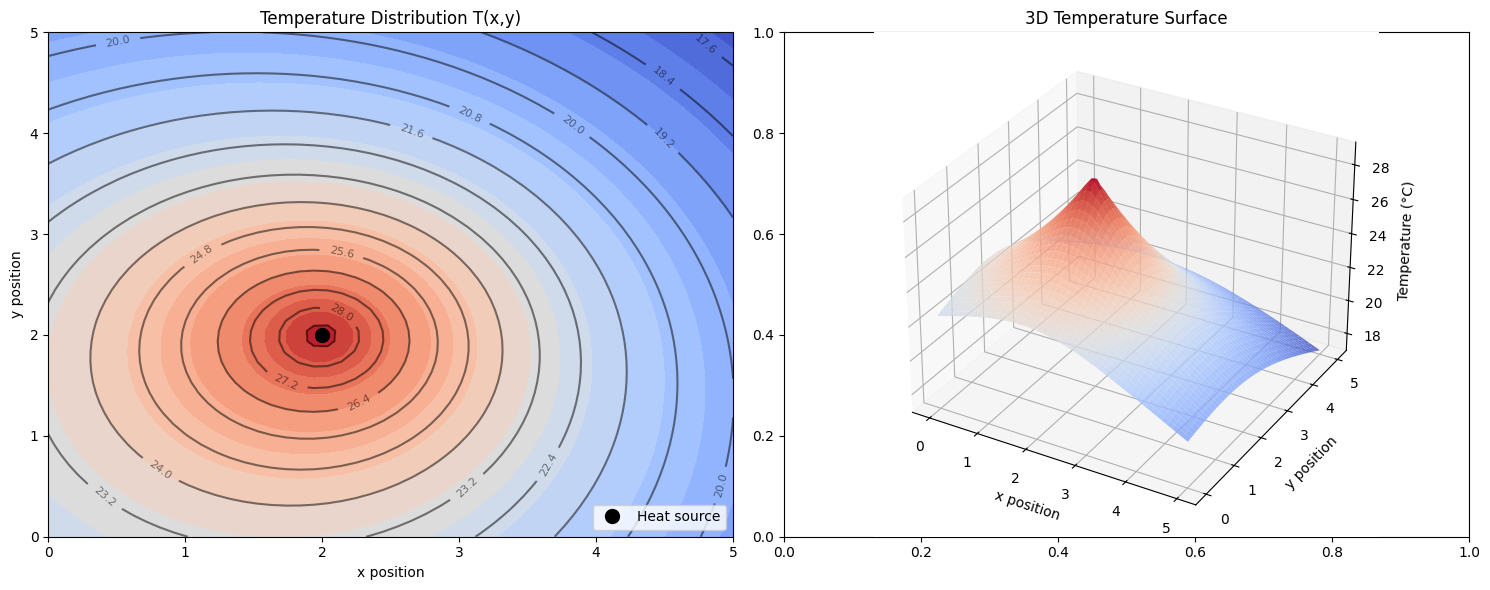

Testing the temperature function at specific locations:
T(1, 1) = 24.8°C
T(2, 2) = 29.4°C
T(4, 4) = 19.9°C
T(0, 0) = 22.4°C


In [2]:
# Simulate a simplified temperature function for a room
# Let's assume the room is 2D for visualization (ignore z and t for now)

def temperature_function(x, y):
    """
    Simplified temperature model for a room
    Assumes a heat source at (2, 2) and cooling near edges
    """
    # Distance from heat source at (2, 2)
    distance_from_heater = np.sqrt((x - 2)**2 + (y - 2)**2)
    
    # Temperature decreases with distance from heater and near edges
    base_temp = 20  # Room temperature
    heat_contribution = 10 * np.exp(-distance_from_heater/2)  # Heat from source
    edge_cooling = -2 * (x**2 + y**2) / 25  # Cooling near edges
    
    return base_temp + heat_contribution + edge_cooling

# Create a grid of points
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 50)
X, Y = np.meshgrid(x, y)

# Calculate temperature at each point
Z = temperature_function(X, Y)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Contour plot
contour = ax1.contour(X, Y, Z, levels=15, colors='black', alpha=0.5)
ax1.contourf(X, Y, Z, levels=20, cmap='coolwarm')
ax1.clabel(contour, inline=True, fontsize=8)
ax1.set_xlabel('x position')
ax1.set_ylabel('y position') 
ax1.set_title('Temperature Distribution T(x,y)')
ax1.plot(2, 2, 'ko', markersize=10, label='Heat source')
ax1.legend()

# 3D surface plot
ax2 = fig.add_subplot(122, projection='3d')
surface = ax2.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8)
ax2.set_xlabel('x position')
ax2.set_ylabel('y position')
ax2.set_zlabel('Temperature (°C)')
ax2.set_title('3D Temperature Surface')

plt.tight_layout()
plt.show()

# Test the function at specific points
test_points = [(1, 1), (2, 2), (4, 4), (0, 0)]
print("Testing the temperature function at specific locations:")
for x_pos, y_pos in test_points:
    temp = temperature_function(x_pos, y_pos)
    print(f"T({x_pos}, {y_pos}) = {temp:.1f}°C")

## The Challenge of Mathematical Notation

Mathematical notation can be confusing and sometimes ambiguous. Let's address some common sources of confusion:

### The $f(x)$ Notation Problem

When we write $f(x) = x^2 + 3$, it means:
- $f$ is the **name** of the function  
- $x$ is the **input variable**
- $f(x)$ is the **output** when we apply function $f$ to input $x$

**Important**: $f(x)$ does **NOT** mean "$f$ multiplied by $x$"!

### Ambiguous Expressions

Consider this expression: $f(x) = \frac{g(x) + h}{a}$

Without context, we don't know:
- Is $g$ a function applied to $x$, or $g$ multiplied by $x$?
- Are $h$ and $a$ constants or functions?
- Is it $\frac{g(x) + h}{a}$ or $g(x) + \frac{h}{a}$?

This is why **context and clear definitions are crucial** in mathematics!

In [3]:
# Examples of notation clarity

# Example 1: Clear function notation
def f(x):
    return x**2 + 3

def g(x): 
    return 2*x + 1

# When we write f(x), we mean "apply function f to input x"
x_val = 5
print(f"f({x_val}) = {f(x_val)}")  # f applied to 5
print(f"g({x_val}) = {g(x_val)}")  # g applied to 5

print("\n" + "="*50)

# Example 2: Demonstrating the ambiguity problem
# Let's say we have: f(x) = (g(x) + h) / a

# Clear version with explicit function definitions:
def clear_function(x):
    h = 10  # h is a constant
    a = 2   # a is a constant  
    return (g(x) + h) / a

# Ambiguous version that could be misinterpreted:
def ambiguous_example(x):
    # Without context, someone might think:
    # - g and x are being multiplied
    # - h and a are variables
    # This leads to confusion!
    pass

print("Clear function definition:")
x_test = 3
result = clear_function(x_test)
print(f"f({x_test}) = (g({x_test}) + 10) / 2 = ({g(x_test)} + 10) / 2 = {result}")

print("\nKey takeaway: Always define your variables and functions clearly!")

f(5) = 28
g(5) = 11

Clear function definition:
f(3) = (g(3) + 10) / 2 = (7 + 10) / 2 = 8.5

Key takeaway: Always define your variables and functions clearly!


## The Creative Essence of Science: Choosing Functions

One of the most important insights about functions is that **selecting the right function to model real-world phenomena is the creative heart of science**.

### The Scientific Process
1. **Observe** a phenomenon in the real world
2. **Hypothesize** a function that might model this phenomenon  
3. **Test** the function against data
4. **Refine** or replace the function based on results

### Examples of Famous Function Selections

| Scientist | Phenomenon | Function Choice | Impact |
|-----------|------------|-----------------|---------|
| Newton | Planetary motion | $F = G\frac{m_1 m_2}{r^2}$ | Classical mechanics |
| Einstein | Mass-energy | $E = mc^2$ | Modern physics |
| Mendel | Inheritance | Discrete probability functions | Genetics |
| Darwin | Evolution | Exponential growth models | Biology |

### In Machine Learning
The same principle applies! We choose functions to:
- Model relationships in data
- Predict future outcomes  
- Classify patterns
- Generate new content

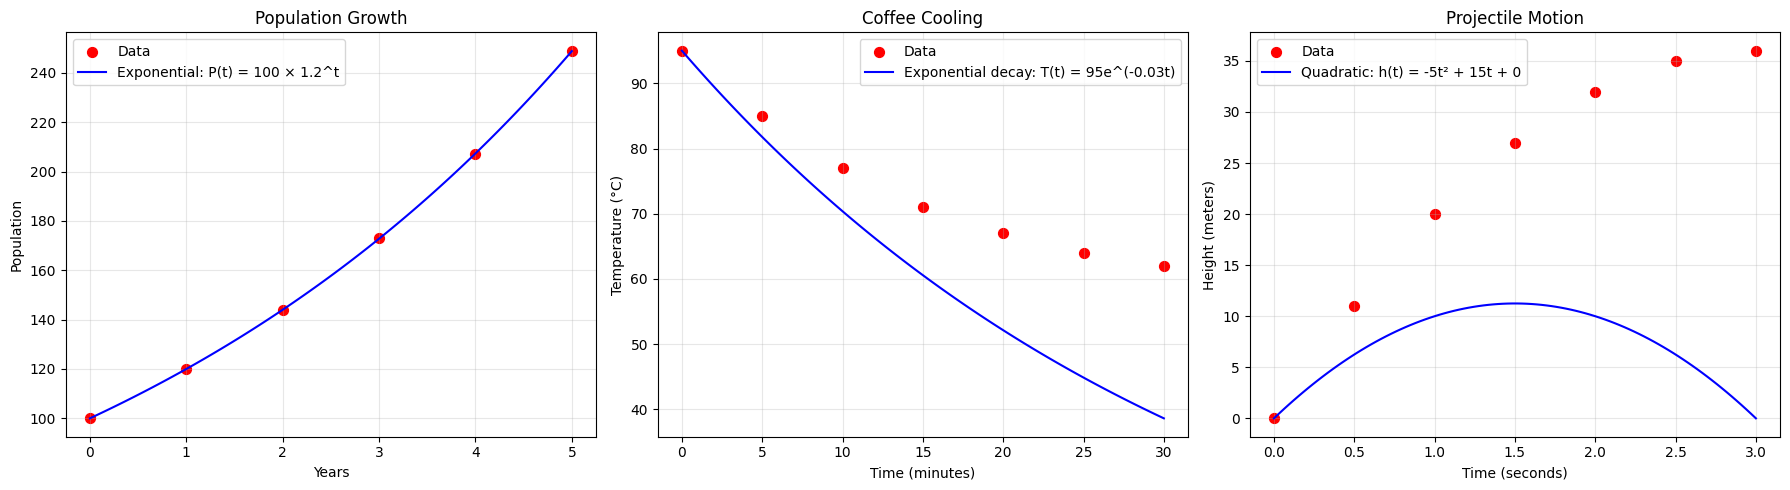

Function Selection Rationale:
1. Population Growth → Exponential function (compound growth)
2. Coffee Cooling → Exponential decay (Newton's law of cooling)
3. Projectile Motion → Quadratic function (physics of gravity)

Each choice reflects understanding of the underlying physical process!


In [4]:
# Interactive Exercise: Function Selection Challenge
# Let's practice selecting appropriate functions for different scenarios

import numpy as np
import matplotlib.pyplot as plt

# Scenario 1: Population growth
years = np.array([0, 1, 2, 3, 4, 5])
population = np.array([100, 120, 144, 173, 207, 249])

# Scenario 2: Cooling coffee temperature  
time_minutes = np.array([0, 5, 10, 15, 20, 25, 30])
temperature = np.array([95, 85, 77, 71, 67, 64, 62])

# Scenario 3: Projectile motion
time_seconds = np.array([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
height_meters = np.array([0, 11, 20, 27, 32, 35, 36])

# Let's try different function types for each scenario
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scenario 1: Try exponential function
def exponential_model(x, a, b):
    return a * (b ** x)

x_smooth = np.linspace(0, 5, 100)
axes[0].scatter(years, population, color='red', s=50, label='Data')
# Fit exponential manually for demonstration
a, b = 100, 1.2  # These would normally be fitted to data
axes[0].plot(x_smooth, exponential_model(x_smooth, a, b), 'b-', 
             label=f'Exponential: P(t) = {a} × {b}^t')
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Population')
axes[0].set_title('Population Growth')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scenario 2: Try exponential decay
def exponential_decay(t, T0, k):
    return T0 * np.exp(-k * t)

t_smooth = np.linspace(0, 30, 100)
axes[1].scatter(time_minutes, temperature, color='red', s=50, label='Data')
T0, k = 95, 0.03  # These would normally be fitted to data
axes[1].plot(t_smooth, exponential_decay(t_smooth, T0, k), 'b-',
             label=f'Exponential decay: T(t) = {T0}e^(-{k}t)')
axes[1].set_xlabel('Time (minutes)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Coffee Cooling')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Scenario 3: Try quadratic function
def quadratic_model(t, a, b, c):
    return a*t**2 + b*t + c

t_smooth = np.linspace(0, 3, 100)
axes[2].scatter(time_seconds, height_meters, color='red', s=50, label='Data')
a, b, c = -5, 15, 0  # These would normally be fitted to data
axes[2].plot(t_smooth, quadratic_model(t_smooth, a, b, c), 'b-',
             label=f'Quadratic: h(t) = {a}t² + {b}t + {c}')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Height (meters)')
axes[2].set_title('Projectile Motion')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Function Selection Rationale:")
print("1. Population Growth → Exponential function (compound growth)")
print("2. Coffee Cooling → Exponential decay (Newton's law of cooling)")  
print("3. Projectile Motion → Quadratic function (physics of gravity)")
print("\nEach choice reflects understanding of the underlying physical process!")

## From Functions to Calculus and Machine Learning

### What is Calculus?
**Calculus is the study of how functions change** with respect to their input variables. It provides tools to:

- **Differentiation**: Find rates of change (slopes, velocities, gradients)
- **Integration**: Find accumulated quantities (areas, volumes, total change)
- **Optimization**: Find maximum and minimum values

### Why Functions Matter in Machine Learning

In machine learning, we use functions to:

1. **Model Relationships**: $y = f(x_1, x_2, ..., x_n)$ where $y$ is our prediction
2. **Loss Functions**: Measure how wrong our predictions are
3. **Activation Functions**: Transform data in neural networks  
4. **Optimization**: Use calculus to find the best model parameters

### The Journey Ahead

```
Functions → Calculus → Machine Learning
    ↓           ↓            ↓
Relationships → Change → Optimization
```

Think of this course as learning a new language - the language of mathematical modeling that powers modern AI and data science!

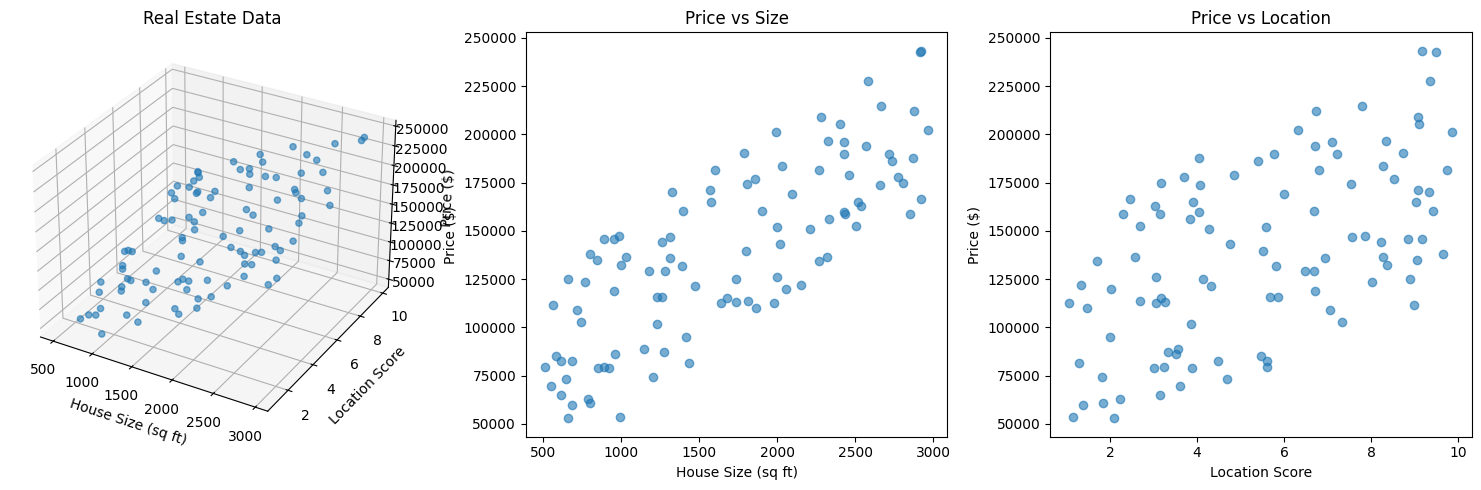

Machine Learning Challenge:
Given this data, which function would you choose to model house prices?

1. Linear: price = w₁×size + w₂×location + b
2. Polynomial: price = w₁×size + w₂×location + w₃×size² + w₄×location² + b
3. Interactive: price = w₁×size + w₂×location + w₃×size×location + b

This is exactly the creative challenge scientists and ML engineers face!
The choice of function determines how well we can model and predict real-world phenomena.


In [5]:
# Example: Functions in Machine Learning
# Let's see how function selection applies to a simple ML problem

# Simulated data: House prices based on size and location
np.random.seed(42)
house_sizes = np.random.uniform(500, 3000, 100)  # Square feet
location_scores = np.random.uniform(1, 10, 100)  # Location quality (1-10)

# True underlying function (unknown in real ML)
def true_price_function(size, location):
    return 50 * size + 10000 * location + np.random.normal(0, 5000, len(size))

prices = true_price_function(house_sizes, location_scores)

# Different function choices for modeling:

# Model 1: Linear function
def linear_model(size, location, w1, w2, b):
    return w1 * size + w2 * location + b

# Model 2: Polynomial function  
def polynomial_model(size, location, w1, w2, w3, w4, b):
    return w1 * size + w2 * location + w3 * size**2 + w4 * location**2 + b

# Model 3: Interactive function
def interactive_model(size, location, w1, w2, w3, b):
    return w1 * size + w2 * location + w3 * size * location + b

# Visualize the relationship
fig = plt.figure(figsize=(15, 5))

# 3D scatter plot of the data
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(house_sizes, location_scores, prices, alpha=0.6)
ax1.set_xlabel('House Size (sq ft)')
ax1.set_ylabel('Location Score')
ax1.set_zlabel('Price ($)')
ax1.set_title('Real Estate Data')

# Show correlation with size
ax2 = fig.add_subplot(132)
ax2.scatter(house_sizes, prices, alpha=0.6)
ax2.set_xlabel('House Size (sq ft)')
ax2.set_ylabel('Price ($)')
ax2.set_title('Price vs Size')

# Show correlation with location
ax3 = fig.add_subplot(133)
ax3.scatter(location_scores, prices, alpha=0.6)
ax3.set_xlabel('Location Score')
ax3.set_ylabel('Price ($)')  
ax3.set_title('Price vs Location')

plt.tight_layout()
plt.show()

print("Machine Learning Challenge:")
print("Given this data, which function would you choose to model house prices?")
print("\n1. Linear: price = w₁×size + w₂×location + b")
print("2. Polynomial: price = w₁×size + w₂×location + w₃×size² + w₄×location² + b") 
print("3. Interactive: price = w₁×size + w₂×location + w₃×size×location + b")
print("\nThis is exactly the creative challenge scientists and ML engineers face!")
print("The choice of function determines how well we can model and predict real-world phenomena.")

## Key Takeaways and Motivation

### What We've Learned About Functions

✅ **Functions are relationships** between inputs and outputs  
✅ **Multi-variable functions** can model complex real-world phenomena  
✅ **Mathematical notation** can be confusing but becomes clearer with practice  
✅ **Function selection** is the creative heart of science and machine learning  
✅ **Calculus studies** how functions change - essential for optimization  

### The Learning Journey Analogy

As mentioned in the lecture, learning mathematics is like learning any language:

> "You can't enjoy French poetry until you've learned a lot of French vocabulary and grammar including all its quirks and irregularities."

Similarly, you need to master mathematical fundamentals before you can appreciate the "poetry" of machine learning!

### Your Mathematical Poetry Awaits

🎯 **Machine Learning** is a whole genre of mathematical poetry  
🎯 **Neural Networks** are compositions of functions  
🎯 **Optimization Algorithms** use calculus to find the best solutions  
🎯 **Data Science** transforms raw data into insights using mathematical functions  

### Remember: It's Normal to Feel Confused!

Even professional mathematicians and data scientists get confused by notation and concepts. The key is persistence and practice. Every expert was once a beginner who kept going despite the confusion.

**Keep going - the mathematical poetry of machine learning is worth the journey!**

## Practice Exercise: Test Your Understanding

Try to answer these questions based on what you've learned:

### Question 1: Function Identification
For each scenario, identify which type of function might be most appropriate:

a) **Bacterial growth in a petri dish over time**  
b) **The path of a thrown ball**  
c) **Temperature change as you move away from a campfire**  
d) **Stock price fluctuations over time**

### Question 2: Notation Clarity
What does each expression mean? Be specific about what's a function vs. what's a variable/constant:

a) $f(x,y) = 3x^2 + 2y - 5$  
b) $g(t) = h(t) \cdot k + m$  
c) $z = f(g(x))$

### Question 3: Real-World Modeling
Imagine you're tasked with modeling:
- **Input**: Hours of study per day, quality of sleep (1-10), stress level (1-10)
- **Output**: Exam performance (0-100)

Write out the function notation and think about what type of relationship might exist.

### Question 4: The Big Picture
Explain in your own words why function selection is considered "the creative essence of science."

In [6]:
# Solutions to Practice Exercise (run this cell to reveal answers)

print("SOLUTIONS TO PRACTICE EXERCISE")
print("="*50)

print("\n1. Function Identification:")
print("a) Bacterial growth → Exponential function (rapid growth)")
print("b) Ball trajectory → Quadratic function (parabolic path due to gravity)")  
print("c) Temperature vs distance → Exponential decay or inverse function")
print("d) Stock prices → Complex (random walk, possibly with trends)")

print("\n2. Notation Clarity:")
print("a) f(x,y) = 3x² + 2y - 5")
print("   → f is a function that takes inputs x and y")
print("   → Output is 3 times x squared plus 2 times y minus 5")
print()
print("b) g(t) = h(t)·k + m")  
print("   → g is a function of t")
print("   → h is also a function of t") 
print("   → k and m appear to be constants")
print()
print("c) z = f(g(x))")
print("   → Composition of functions: first apply g to x, then apply f to the result")

print("\n3. Real-World Modeling:")
print("Function notation: performance = f(study_hours, sleep_quality, stress_level)")
print("Possible relationship: Performance increases with study time and sleep quality,")
print("but decreases with stress level. Might be linear or have interactions.")

print("\n4. The Big Picture:")
print("Function selection is creative because:")
print("• It requires insight into underlying mechanisms")
print("• There are infinite possible functions to choose from")  
print("• The choice determines what we can discover and predict")
print("• Great scientists are remembered for brilliant function choices")
print("• It bridges abstract math and real-world understanding")

print("\n" + "="*50)
print("Great job working through these concepts!")
print("You're building the foundation for calculus and machine learning!")

SOLUTIONS TO PRACTICE EXERCISE

1. Function Identification:
a) Bacterial growth → Exponential function (rapid growth)
b) Ball trajectory → Quadratic function (parabolic path due to gravity)
c) Temperature vs distance → Exponential decay or inverse function
d) Stock prices → Complex (random walk, possibly with trends)

2. Notation Clarity:
a) f(x,y) = 3x² + 2y - 5
   → f is a function that takes inputs x and y
   → Output is 3 times x squared plus 2 times y minus 5

b) g(t) = h(t)·k + m
   → g is a function of t
   → h is also a function of t
   → k and m appear to be constants

c) z = f(g(x))
   → Composition of functions: first apply g to x, then apply f to the result

3. Real-World Modeling:
Function notation: performance = f(study_hours, sleep_quality, stress_level)
Possible relationship: Performance increases with study time and sleep quality,
but decreases with stress level. Might be linear or have interactions.

4. The Big Picture:
Function selection is creative because:
• It req